In [1]:
import pandas as pd
import sys
import os 
import numpy as np
import matplotlib.pyplot as plt
import pickle
import reconstructing
import stats 
import math 


sys.path.append(os.path.abspath(".."))

from initial_solution import jigs_initial_sequence


In [2]:
directory_path = r"path/to/sa_results"


In [3]:
frontier = pd.read_csv(os.path.join(directory_path, "pareto_frontier_summary.csv"))
print("Pareto Frontier",frontier.head(20))

Pareto Frontier       cost     tardiness       severity
0  30720.0  3.100069e+08  422928.955619
1  31360.0  4.766796e+07  127114.553810
2  31840.0  1.087200e+05    3624.001442
3  31840.0  5.551911e+04    3701.273673
4  32160.0  0.000000e+00       0.000000


In [4]:
print("Min cost of the frontier",frontier["cost"].min(),"£")
print("Min tardiness of the frontier",frontier["tardiness"].min(),"sec")
print("Min Severity of the frontier",frontier["severity"].min())

Min cost of the frontier 30720.0 £
Min tardiness of the frontier 0.0 sec
Min Severity of the frontier 0.0


In [5]:
chosen_index = frontier.iloc[4].name
print("Chosen index:", chosen_index)

print("Cost best solution",frontier.loc[chosen_index]["cost"],"£")
print("Tardiness best solution",(frontier.loc[chosen_index]["tardiness"])/3600,"h")
print("Severity best solution",(frontier.loc[chosen_index]["severity"])/3600,"h")


Chosen index: 4
Cost best solution 32160.0 £
Tardiness best solution 0.0 h
Severity best solution 0.0 h


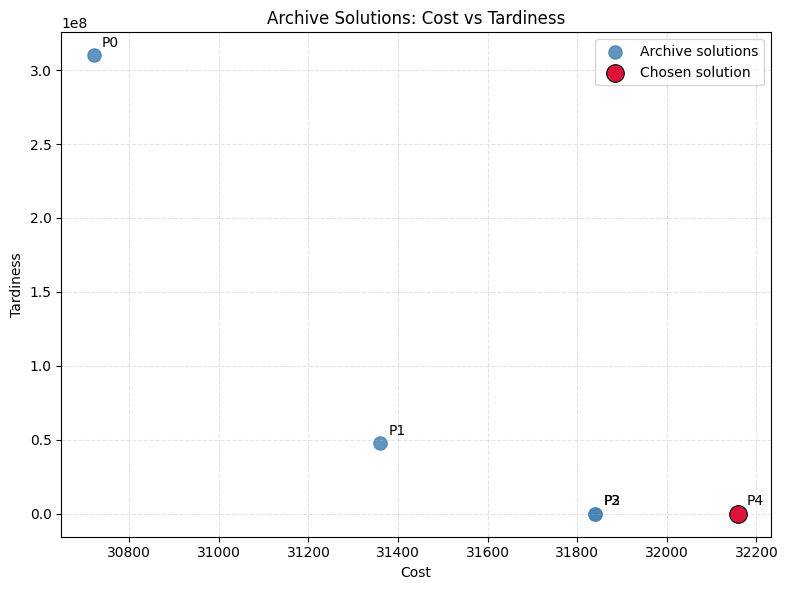

In [6]:
# Archive-style scatter: cost vs tardiness
frontier["label"] = [f"P{i}" for i in range(len(frontier))]

fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(
    frontier["cost"],
    frontier["tardiness"],
    s=90,
    color="steelblue",
    alpha=0.85,
    label="Archive solutions",
)

chosen_point = frontier.loc[chosen_index]
ax.scatter(
    chosen_point["cost"],
    chosen_point["tardiness"],
    s=160,
    color="crimson",
    edgecolor="black",
    linewidth=0.8,
    label="Chosen solution",
    zorder=3,
)

for _, row in frontier.iterrows():
    ax.annotate(
        row["label"],
        (row["cost"], row["tardiness"]),
        textcoords="offset points",
        xytext=(6, 6),
    )

ax.set_xlabel("Cost")
ax.set_ylabel("Tardiness")
ax.set_title("Archive Solutions: Cost vs Tardiness")
ax.grid(True, linestyle="--", alpha=0.35)
ax.legend()

plt.tight_layout()
plt.show()

In [7]:
#Import the pickle file of my pareto archive :)

pkl_path = os.path.join(directory_path, "pareto_archive.pkl")



with open(pkl_path, "rb") as f:
    pareto_archive = pickle.load(f)

print(type(pareto_archive))
print("Number of archive entries:", len(pareto_archive))
print("First entry keys:", pareto_archive[0].keys())



<class 'list'>
Number of archive entries: 5
First entry keys: dict_keys(['solution', 'result', 'objectives'])


In [8]:
# Select the best solution search 
entry = pareto_archive[chosen_index]

print("Objectives:", entry["objectives"])

Objectives: [32160.     0.     0.]


In [9]:
# Read my input data :)

data_path = r"path/to/your_input_file.csv"
data = pd.read_csv(data_path)
data['deadline'] = pd.to_datetime(data['deadline'], dayfirst=True, errors='coerce')
start_date = data['deadline'].min() - pd.Timedelta(days=7) # I suppose for all my products the design is ready one week in advance 
data['DeadlineSeconds'] = (data['deadline'] - start_date).dt.total_seconds().astype(float)

notebook_cell.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data['deadline'] = pd.to_datetime(data['deadline'], dayfirst=True, errors='coerce')


In [10]:
# Problem Parameters!!!
multi_workers_efficiency=0.9
jigs_capacity=4
max_jigs=4
staff_cost=20
Day_work_time= 8 * 3600



In [11]:
# Here I am reconstructing my product schedule based on the best solution 


job_sequence_init, staffing_plan_init, data_sorted_init= jigs_initial_sequence(
    data,
    start_date,
    efficiency_alpha=multi_workers_efficiency,
    T_max=Day_work_time,
    n_stations=max_jigs,
    active_stations=2,
    workers_per_active_station=2,
)



final_schedule = reconstructing.builder(
    entry=entry,
    data=data_sorted_init,
    start_date=start_date,
    T_max=Day_work_time,
    efficiency_alpha=multi_workers_efficiency,
)


final_schedule.to_csv("final_schedule.csv")

In [12]:
# Time KPIs on delays



time_stats, agg_delay = stats.time_stats(
    fs=final_schedule,
    staffing_plan=entry["solution"]["staffing_plan"],
    start_date=start_date,
    worker_hourly_cost=staff_cost,
    tardiness_vector=entry["result"]["tardiness_vector"],
    T_max=Day_work_time,
)



time_stats.to_csv("time_stats.csv")
agg_delay.to_csv("agg_delay.csv")

In [13]:
# Stations KPIs on efficiency 


station_day_stats, station_summary = stats.split_jobs_by_day(
    fs=final_schedule,
    day_work_time=Day_work_time,
)



station_day_stats.to_csv("station_day_stats.csv")
station_summary.to_csv("station_summary.csv")



In [14]:

makespan_sec = entry["result"]["makespan"]
makespan_days = math.ceil(makespan_sec / (24 * 3600))

print("Makespan [sec]:", makespan_sec)
print("Makespan [days]:", makespan_days)


with open("makespan_days.txt", "w") as f:
    f.write(f"Makespan (seconds): {makespan_sec}\n")
    f.write(f"Makespan (days): {makespan_days}\n")

Makespan [sec]: 2188231.1654496174
Makespan [days]: 26
